In [3]:
import os
from pathlib import Path

import pandas as pd
import numpy as np
from dotenv import load_dotenv

# Load environment variables
load_dotenv()

# NeuroAlign-preprocess
# from neuroalign_preprocessing.loaders import AnatomicalLoader, DiffusionLoader, QuestionnaireLoader
# from neuroalign_preprocessing.preprocessing import FeatureStore

_ = load_dotenv()


In [4]:
# Helper to get paths from env
def get_path(var: str) -> Path | None:
    val = os.getenv(var)
    return Path(val).expanduser() if val else None


# Print current configuration
print("Current Configuration:")
print(f"  SESSIONS_CSV: {get_path('SESSIONS_CSV')}")
print(f"  CAT12_ROOT: {get_path('CAT12_ROOT')}")
print(f"  CAT12_ATLAS_ROOT: {get_path('CAT12_ATLAS_ROOT')}")
print(f"  QSIPARC_PATH: {get_path('QSIPARC_PATH')}")
print(f"  QSIRECON_PATH: {get_path('QSIRECON_PATH')}")
print(f"  ATLAS_NAME: {os.getenv('ATLAS_NAME', '4S456Parcels')}")


Current Configuration:
  SESSIONS_CSV: /home/galkepler/Downloads/linked_sessions.csv
  CAT12_ROOT: /media/storage/yalab-dev/BIDS/derivatives/CAT12.9_2577.new
  CAT12_ATLAS_ROOT: /media/storage/yalab-dev/voxelops/Schaefer2018Tian2020_atlases
  QSIPARC_PATH: /mnt/62/Processed_Data/derivatives/qsiparc
  QSIRECON_PATH: /mnt/62/Processed_Data/derivatives/qsirecon
  ATLAS_NAME: Schaefer2018N400n7Tian2020S3


In [5]:
DATA_DIR = Path("/media/storage/neuroalign/data")

In [6]:
# # Load the feature store
# store = FeatureStore(DATA_DIR)

# # Check if store exists
# if store.exists():
#     print("FeatureStore found!")
#     summary = store.summary()
#     print(f"\nSummary:")
#     print(f"  Sessions: {summary['n_sessions']}")
#     print(f"  Subjects: {summary['n_subjects']}")
#     print(f"  Atlas: {summary['atlas_name']}")
#     print(f"  Has TIV: {summary['has_tiv']}")
#     print(f"  Created: {summary['created_at']}")

#     print(f"\nLong formats available: {len(summary['long_formats'])}")
#     for fmt in summary["long_formats"]:
#         print(f"  - {fmt}")

#     print(f"\nWide features available: {summary['n_wide_features']}")
# else:
#     print("FeatureStore not found - run the pipeline first!")


In [7]:
# metric = "anatomical_gm"
# metric_long = store.load_long(metric)

In [8]:
# print(f"Loaded long format for metric '{metric}':")
# display(metric_long.head())

In [9]:
# load parcels
atlas_root = get_path("CAT12_ATLAS_ROOT")
atlas_name = os.getenv("ATLAS_NAME", "4S456Parcels")
parcels_path = atlas_root / f"atlas-{atlas_name}" / f"atlas-{atlas_name}_dseg.tsv"
parcels = pd.read_csv(parcels_path, sep="\t")

In [10]:
# print(f"Found {metric_long['subject_code'].nunique()} unique subjects in the metric long format.")
# metadata = store.load_metadata()
# print(f"Found {metadata['subject_code'].nunique()} unique subjects in the metadata.")


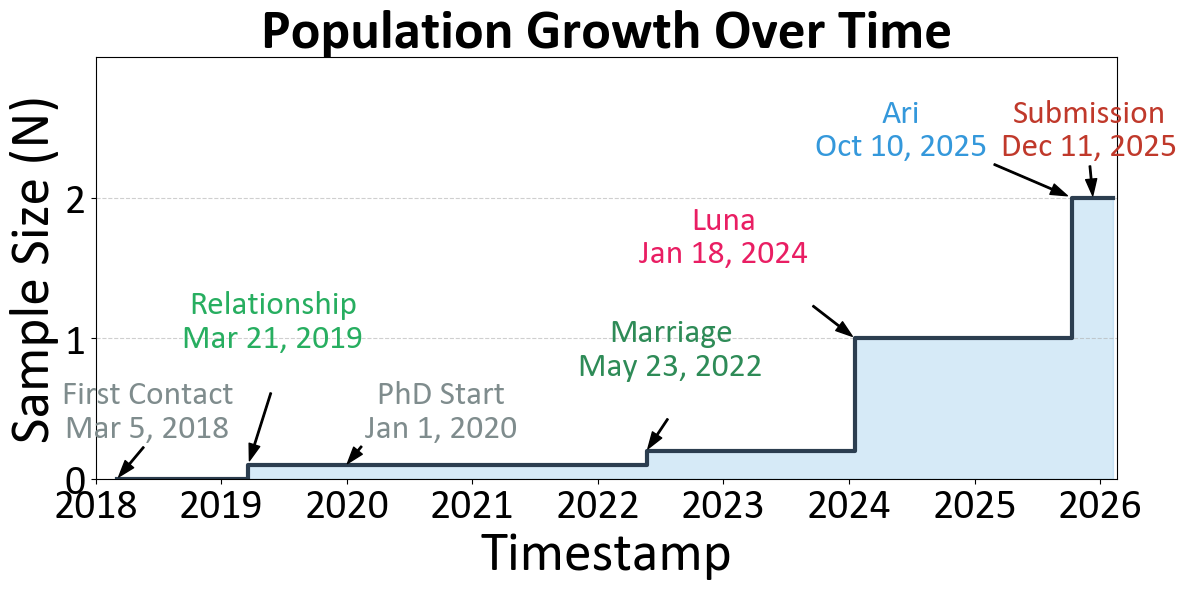

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime

# set calibri font
plt.rcParams["font.family"] = "Calibri"

# Data points
dates = [
    datetime(2018, 3, 5),
    datetime(2019, 3,21),  # Start of relationship
    datetime(2020, 1, 1),   # Start of PhD
    datetime(2022, 5, 23), # Marriage
    datetime(2024, 1, 18),  # Luna's Birthday
    datetime(2025, 10, 10), # Ari's Birthday
    datetime(2025, 12, 11), # submission date
    datetime(2026, 2, 8)    # Today / Defense / The Gathering

]
children_count = [0, 0.1, 0.1, 0.2, 1, 2, 2, 2]
labels = ["First Contact\n(N=0)", "Relationship Start\n(N=0.1)", "PhD Start\n(N=0)", "Marriage\n(N=0.2)", "Luna Born\n(N=1)", "Ari Born\n(N=2)", "Submission" ,"Steady State\n(PhD End)"]

# Plotting
fig, ax = plt.subplots(figsize=(12, 6))

# Create the step/bar look
ax.step(dates, children_count, where='post', color='#2c3e50', linewidth=3, label='Cumulative N')
ax.fill_between(dates, children_count, step="post", alpha=0.2, color='#3498db')

# create "trajectories" for the children
# ax.plot([datetime(2020, 1, 1), datetime(2024, 1, 18)], [0, 1], color='#e91e63', linestyle='--', linewidth=2)
# ax.plot([datetime(2024, 1, 18), datetime(2025, 10, 10)], [1, 2], color='#3498db', linestyle='--', linewidth=2)

# Annotations for the milestones
ax.annotate(f"First Contact\nMar 5, 2018", 
            xy=(datetime(2018, 3, 5), 0), xytext=(datetime(2018, 6, 1), 0.3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make color dark gray
            color='#7f8c8d',
            # center align text
            ha='center'
            )

ax.annotate(f"Relationship\nMar 21, 2019\n", 
            xy=(datetime(2019, 3, 21), 0.1), xytext=(datetime(2019, 6, 1), 0.7),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make color light green
            color='#27ae60',
            # center align text
            ha='center'
            )

ax.annotate(f"PhD Start\nJan 1, 2020", 
            xy=(datetime(2020, 1, 1), 0.1), xytext=(datetime(2020, 10, 1), 0.3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make color dark gray
            color='#7f8c8d',
            # center align text
            ha='center'
            )

ax.annotate(f"Marriage\nMay 23, 2022\n",
            xy=(datetime(2022, 5, 23), 0.2), xytext=(datetime(2022, 8, 1), 0.5),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make color dark green
            color='#2e8b57',
            # center align text
            ha='center'
            )
# Annotations for the children
ax.annotate(f'Luna\nJan 18, 2024\n', 
            xy=(datetime(2024, 1, 18), 1), xytext=(datetime(2023, 1, 1), 1.3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make color dark pink
            color='#e91e63',
            # center align text
            ha='center'
            )

ax.annotate(f'Ari\nOct 10, 2025', 
            xy=(datetime(2025, 10, 10), 2), xytext=(datetime(2024, 6, 1), 2.3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make dark blue
            color='#3498db',
            # center align text
            ha='center')

ax.annotate(f'Submission\nDec 11, 2025',
            xy=(datetime(2025, 12, 11), 2), xytext=(datetime(2025, 12, 1), 2.3),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8), fontsize=24,
            # make dark red
            color='#c0392b',
            # center align text
            ha='center')

# Formatting
ax.set_ylim(0, 3)
ax.set_yticks([0, 1, 2])
# enlrage yticks
ax.tick_params(axis='both', labelsize=30)
# ax.set_yticklabels(['Baseline (0)', 'Luna (1)', 'Critical Mass (2)'])
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.title("Population Growth Over Time", fontsize=40, fontweight='bold')
plt.xlabel("Timestamp", fontsize=40)
plt.ylabel("Sample Size (N)", fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# set xlim to be from 2018 to today
ax.set_xlim(datetime(2018, 1, 1), datetime(2026, 2, 19))


plt.tight_layout()
plt.savefig("/home/galkepler/Downloads/phd_concluding_fig1.png", dpi=300, transparent=True)

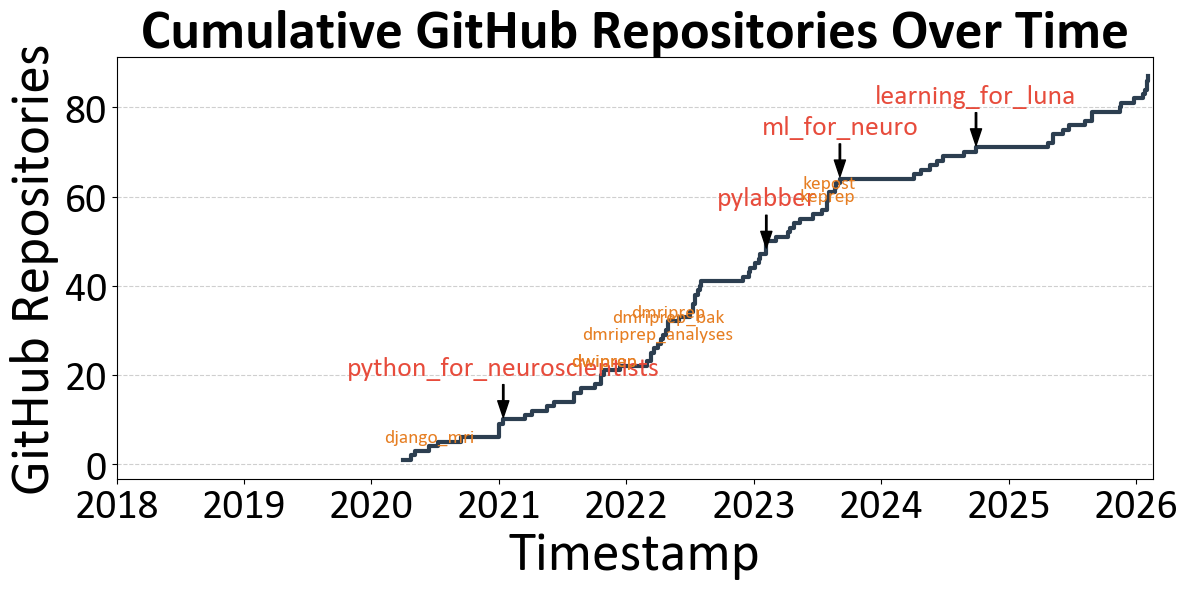

In [15]:
import pandas as pd

repos = pd.read_json("/home/galkepler/Downloads/my_repos.json").sort_values("createdAt").reset_index(drop=True)
repos["count"] = repos.index + 1
repos["timestamp"] = pd.to_datetime(repos["createdAt"])

# fill to match earlier timestamp


honorable_mentions = ["dwiprep", "django_mri", "python_for_neuroscientists", "dwiprep", "dmriprep_analyses", "dmriprep_bak","dmriprep","pylabber","keprep","kepost","ml_for_neuro", "learning_for_luna"]
highlight = ["python_for_neuroscientists", "pylabber", "ml_for_neuro", "learning_for_luna"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.step(repos["timestamp"], repos["count"], where='post', color='#2c3e50', linewidth=3, label='Cumulative Repos')
for repo in honorable_mentions:
    repo_date = repos[repos["name"] == repo]["timestamp"].values
    if len(repo_date) > 0:
        if repo in highlight:
            ax.annotate(repo,
                        xy=(repo_date[0], repos[repos["name"] == repo]["count"].values[0]), 
                        xytext=(repo_date[0] - 5, repos[repos["name"] == repo]["count"].values[0] + 10),
                        arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=8),
                        fontsize=20,
                        color='#e74c3c',
                        ha='center')
        else:
            ax.annotate(repo,
                        xy=(repo_date[0], repos[repos["name"] == repo]["count"].values[0] + 5), 
                        xytext=(repo_date[0], repos[repos["name"] == repo]["count"].values[0] + 1),
                        fontsize=14,
                        color='#e67e22',
                        ha='center')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.title("Cumulative GitHub Repositories Over Time", fontsize=40, fontweight='bold')
plt.xlabel("Timestamp", fontsize=40)
plt.ylabel("GitHub Repositories", fontsize=40)
ax.set_xlabel("Timestamp", fontsize=40)
plt.grid(axis='y', linestyle='--', alpha=0.6)
ax.tick_params(axis='both', labelsize=30)

# set xlim to be from 2018 to today
ax.set_xlim(datetime(2018, 1, 1), datetime(2026, 2, 19))

plt.tight_layout()
plt.savefig("/home/galkepler/Downloads/phd_concluding_fig2.png", dpi=300, transparent=True)

In [36]:
tiv_df = store.load_tiv()

In [37]:
from neuroalign.modeling import RegionalBAGEstimator, BAGConfig
from neuroalign.utils import configure_logging
import logging

configure_logging(level="INFO")
print("Logging has been configured!")


2026-02-08 11:05:19,508 - root - INFO - Logging configured to level INFO
Logging has been configured!


In [38]:

config = BAGConfig(
    model_type="ridge",
    n_splits=20,
    bias_correction=True,
    progress=True,
    n_jobs = 20,
    ipw=False,
    polynomial_degree=3,
    splits="group_kfold",
    tiv_col="tiv_null" if "anatomical" in metric and "ct" in metric else "tiv",
)
metric_long["tiv_null"] = 1.0  # add null TIV for cortical thickness

estimator = RegionalBAGEstimator(config)
# Configure logging to display INFO level messages (or DEBUG for more verbose output)

# Convert long format to wide
features_wide = RegionalBAGEstimator.long_to_wide(
    metric_long, metric_col="mean", region_col="index"
)

# Build metadata DataFrame
meta = metadata[["subject_code", "session_id", "Age@Scan", "Gender"]].copy()
meta = meta.merge(metric_long, on=["subject_code", "session_id"])
meta = meta.rename(columns={"Age@Scan": "age", "Gender": "sex"}).drop_duplicates(subset=["subject_code","session_id"])

# drop participants younger than 18
meta = meta[meta["age"] >= 18]

In [39]:
# Compute BAGs
result = estimator.fit_predict(features_wide, meta)

2026-02-08 11:06:52,088 - neuroalign.modeling.univariate.estimator - INFO - Starting regional BAG estimation.
2026-02-08 11:06:52,092 - neuroalign.modeling.univariate.estimator - INFO - Input features: 4344 rows, 452 columns.
2026-02-08 11:06:52,093 - neuroalign.modeling.univariate.estimator - INFO - Input metadata: 4331 rows, 24 columns.
2026-02-08 11:06:52,245 - neuroalign.modeling.univariate.estimator - INFO - Merged data: 4330 rows, 474 columns.
2026-02-08 11:06:52,251 - neuroalign.modeling.univariate.estimator - INFO - Encoding sex: {'Female': 0, 'Male': 1}
2026-02-08 11:06:52,254 - neuroalign.modeling.univariate.estimator - INFO - Fitting 450 regions across 4330 sessions.
2026-02-08 11:06:52,275 - neuroalign.modeling.univariate.estimator - INFO - Starting 20-fold cross-validation.


Fold 1/20:   0%|          | 0/450 [00:00<?, ?it/s]

Fold 2/20:   0%|          | 0/450 [00:00<?, ?it/s]

Fold 3/20:   0%|          | 0/450 [00:00<?, ?it/s]

Fold 4/20:   0%|          | 0/450 [00:00<?, ?it/s]

...

Fold 17/20:   0%|          | 0/450 [00:00<?, ?it/s]

Fold 18/20:   0%|          | 0/450 [00:00<?, ?it/s]

Fold 19/20:   0%|          | 0/450 [00:00<?, ?it/s]

Fold 20/20:   0%|          | 0/450 [00:00<?, ?it/s]

2026-02-08 11:07:17,149 - neuroalign.modeling.univariate.estimator - INFO - Cross-validation finished.
2026-02-08 11:07:17,151 - neuroalign.modeling.univariate.estimator - INFO - Assembling results.
2026-02-08 11:07:17,202 - neuroalign.modeling.univariate.estimator - INFO - Applying bias correction.
2026-02-08 11:07:17,600 - neuroalign.modeling.univariate.estimator - INFO - Computing region-wise metrics.
2026-02-08 11:07:18,537 - neuroalign.modeling.univariate.estimator - INFO - BAG estimation complete.


In [47]:
# create a dendogram of the correlations between regional BAGs across sessions
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt
# Compute correlation matrix of regional BAGs
regional_bags = result.bag.drop(columns=["subject_code"]).set_index("session_id")
corr_matrix = regional_bags.T.corr()

# calculate the distance matrix for hierarchical clustering
distance_matrix = 1 - corr_matrix.abs()



In [53]:
distance_matrix_long = distance_matrix.stack().reset_index(allow_duplicates=True)
distance_matrix_long.columns = ["session_i", "session_j", "distance"]

In [59]:
# visualize with-subject distances against between-subject distances
from tqdm import tqdm

# Get unique sessions and their corresponding subjects
sessions = meta[["session_id", "subject_code"]].drop_duplicates()
session_to_subject = dict(zip(sessions["session_id"], sessions["subject_code"]))
# Add subject information to the distance matrix
distance_matrix_long["subject_i"] = distance_matrix_long["session_i"].map(session_to_subject)
distance_matrix_long["subject_j"] = distance_matrix_long["session_j"].map(session_to_subject)
distance_matrix_long["same_subject"] = distance_matrix_long["subject_i"] == distance_matrix_long["subject_j"]
distance_matrix_long = distance_matrix_long.drop_duplicates(subset=["session_i", "session_j"])
# distance between session i and session j is the same as between session j and session i, so we can drop duplicates
distance_matrix_long = distance_matrix_long[distance_matrix_long["session_i"] < distance_matrix_long["session_j"]]

In [ ]:
# distance_matrix_long[(distance_matrix_long["same_subject"] == True) & (distance_matrix_long["distance"] >0.5)].sort_values("distance", ascending=False)
sns.lineplot(data=metadata[metadata["ID"].isin([308418185])], x="time", y="value", hue="variable")

,subject_code,session_id,Age@Scan,ScanID,Status,Lab,Name,ID,Cellular No.,Email,...,HebrewName,No of Scan,PrivacyStatement,UID,dicom_path,match_type,anatomical_gm_loaded,anatomical_wm_loaded,anatomical_ct_loaded,diffusion_loaded
50,PTRL01,202601151222,32.826831,20260115_1222,Performed,YA,Gal Kepler,308418185.0,509024295,Galkepler@gmail.com,...,גל קפלר,2.0,"11/30/2025: Yes, 08/31/2023: Yes, 11/29/2022: ...",None,/mnt/62/Raw_Data/20260115_1222,exact,True,True,True,False
231,PTRL01,202511301100,32.700000,20251130_1100,Performed,YA,Gal Kepler,308418185.0,None,None,...,None,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,None,missing,False,False,False,False
1846,0110,202407141309,31.320000,20240714_1309,Performed,YA,Gal Kepler,308418185.0,None,galkepler@gmail.com,...,גל קפלר,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20240714_1309,exact,True,True,True,False
2510,BB00617,202308311652,30.450000,20230831_1652,Performed,SNBB,Gal Kepler,308418185.0,509024295,galkepler@gmail.com,...,גל קפלר,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20230831_1652,exact,True,True,True,False
3123,0110R,202212061427,29.710000,20221206_1427,Performed,YA,Gal Kepler,308418185.0,050-9024295,galkepler@gmail.com,...,גל קפלר,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20221206_1427,exact,True,True,True,False
3145,0110R,202211291534,29.690000,20221129_1534,Performed,YA,Gal Kepler,308418185.0,050-9024295,galkepler@gmail.com,...,גל קפלר,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20221129_1534,exact,True,True,True,False
4369,0110,202005101058,27.140000,20200510_1058,Performed,YA,Gal Hershcovitz,308418185.0,050-9024295,hershkovitz1@mail.tau.ac.il,...,גל הרשקוביץ,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20200510_1058,exact,True,True,True,False
4414,0110,201911281302,26.690000,20191128_1302,Performed,YA,Gal Hershcovitz,308418185.0,050-9024295,hershkovitz1@mail.tau.ac.il,...,גל הרשקוביץ,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20191128_1302,exact,False,False,False,False
4602,0110,201812061459,25.710000,20181206_1459,Performed,YA,Gal Hershkovitz,308418185.0,None,None,...,גל הרשקוביץ,8.0,"08/31/2023: Yes, 11/29/2022: Yes, 05/10/2020: ...",S000362,/mnt/62/Raw_Data/20181206_1459,exact,True,True,True,False


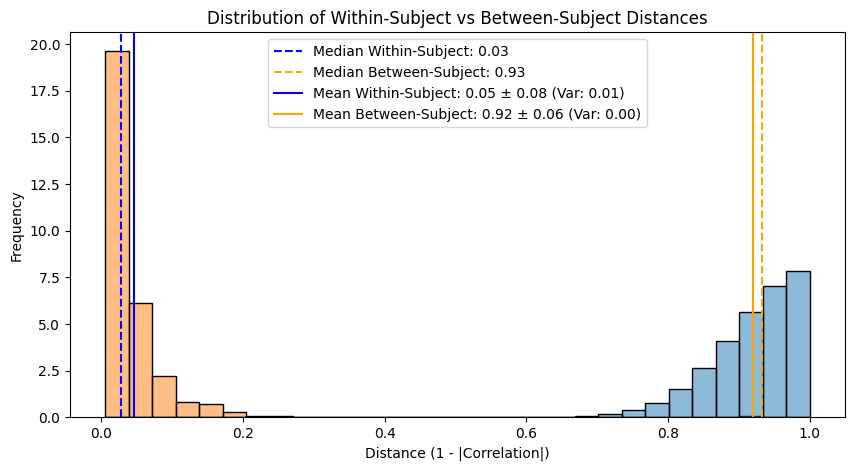

In [64]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.histplot(data=distance_matrix_long,
             x="distance",
             hue="same_subject",
             bins=30,
             alpha=0.5,
            #  multiple="stack",
            stat="density",
            common_norm=False)  
# add median and mean lines, report std and variance in the legend
median_within = distance_matrix_long[distance_matrix_long["same_subject"] == True]["distance"].median()
median_between = distance_matrix_long[distance_matrix_long["same_subject"] == False]["distance"].median()
mean_within = distance_matrix_long[distance_matrix_long["same_subject"] == True]["distance"].mean()
mean_between = distance_matrix_long[distance_matrix_long["same_subject"] == False]["distance"].mean()
std_within = distance_matrix_long[distance_matrix_long["same_subject"] == True]["distance"].std()
std_between = distance_matrix_long[distance_matrix_long["same_subject"] == False]["distance"].std()
var_within = distance_matrix_long[distance_matrix_long["same_subject"] == True]["distance"].var()
var_between = distance_matrix_long[distance_matrix_long["same_subject"] == False]["distance"].var()
plt.axvline(median_within, color="blue", linestyle="--", label=f"Median Within-Subject: {median_within:.2f}")
plt.axvline(median_between, color="orange", linestyle="--", label=f"Median Between-Subject: {median_between:.2f}")
plt.axvline(mean_within, color="blue", linestyle="-", label=f"Mean Within-Subject: {mean_within:.2f} ± {std_within:.2f} (Var: {var_within:.2f})")
plt.axvline(mean_between, color="orange", linestyle="-", label=f"Mean Between-Subject: {mean_between:.2f} ± {std_between:.2f} (Var: {var_between:.2f})")
plt.xlabel("Distance (1 - |Correlation|)")
plt.ylabel("Frequency")
plt.title("Distribution of Within-Subject vs Between-Subject Distances")
plt.legend()
plt.show()


In [23]:
# build a Ridge regression model to predict age from regional BAGs. use group k-fold cross-validation based on subject_code.
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GroupKFold

n_folds = 20

bag_features = result.predicted_age.set_index(["subject_code", "session_id"])
age = meta.set_index(['subject_code', 'session_id']).loc[bag_features.index, 'age']

ridge = RidgeCV(alphas=np.logspace(-6, 6, 13))
groups = bag_features.index.get_level_values("subject_code")
gkf = GroupKFold(n_splits=n_folds)
scores = cross_val_score(ridge, bag_features, age, groups=groups, cv=gkf, scoring='neg_mean_absolute_error', n_jobs=10)
predicted_age = cross_val_predict(ridge, bag_features, age, groups=groups, cv=gkf, n_jobs=10)


/home/galkepler/misc/fsl/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/galkepler/misc/fsl/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/home/galkepler/misc/fsl/lib/python3.11/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setu

In [24]:
predicted_bag = predicted_age - age
A = np.column_stack([age.values, np.ones_like(age.values)])
coeffs, *_ = np.linalg.lstsq(A, predicted_bag.values, rcond=None)
bias_corrected = predicted_bag - (coeffs[0]*age.values + coeffs[1])

# apply correction to predicted age
bias_corrected_age = predicted_age - (coeffs[0]*age.values + coeffs[1])

In [25]:
cols = ['subject_code', 'session_id', 'age', 'sex']
bias_corrected_df = meta[cols].dropna(subset=["subject_code","age","session_id"]).set_index(['subject_code', 'session_id'])
bias_corrected_df['predicted_age_uncorrected'] = pd.Series(predicted_age, index=age.index)
bias_corrected_df['predicted_age_corrected'] = pd.Series(bias_corrected_age, index=age.index)
bias_corrected_df['BAG_uncorrected'] = pd.Series(predicted_bag, index=age.index)
bias_corrected_df['BAG_corrected'] = pd.Series(bias_corrected, index=age.index)

In [33]:
# bias_corrected_df.to_csv("~/Downloads/BAGs_for_yaniv.csv")
# bias_corrected_df.reset_index()

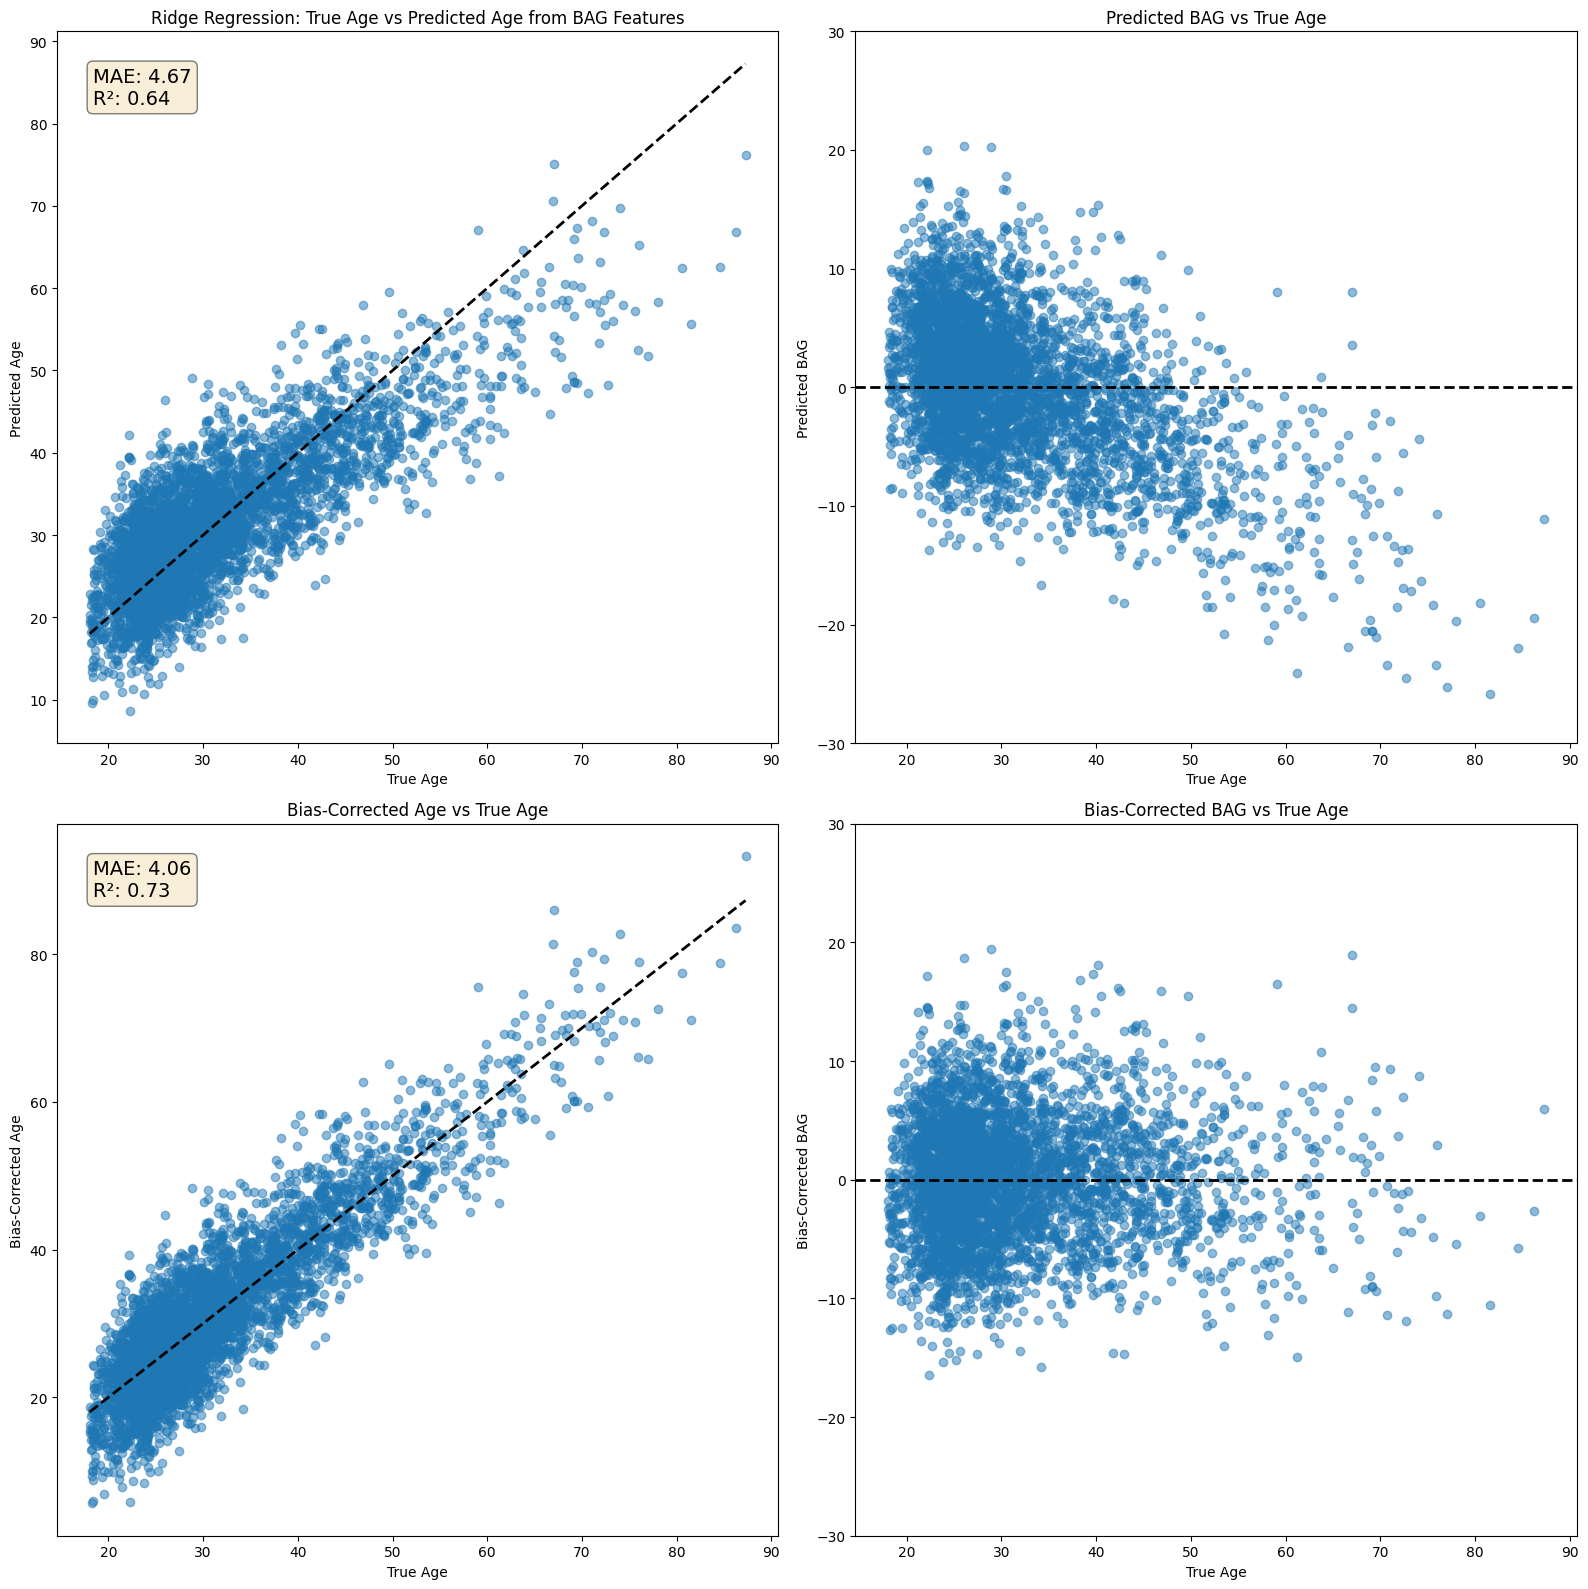

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error
fig, axes = plt.subplots(2,2,figsize=(16, 16))
axes[0,0].scatter(age, predicted_age, alpha=0.5)
axes[0,0].plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
axes[0,0].set_xlabel('True Age')
axes[0,0].set_ylabel('Predicted Age')
axes[0,0].set_title('Ridge Regression: True Age vs Predicted Age from BAG Features')
# add text box with mae, R2
mae = mean_absolute_error(age, predicted_age)
r2 = r2_score(age, predicted_age)
textstr = f'MAE: {mae:.2f}\nR²: {r2:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axes[0,0].text(0.05, 0.95, textstr, transform=axes[0,0].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)


axes[0,1].scatter(age, predicted_bag, alpha=0.5)
axes[0,1].axhline(0, color='k', linestyle='--', lw=2)
axes[0,1].set_ylim(-30, 30)
axes[0,1].set_xlabel('True Age')
axes[0,1].set_ylabel('Predicted BAG')
axes[0,1].set_title('Predicted BAG vs True Age')


axes[1,0].scatter(age, bias_corrected_age, alpha=0.5)
axes[1,0].plot([age.min(), age.max()], [age.min(), age.max()], 'k--', lw=2)
axes[1,0].set_xlabel('True Age')
axes[1,0].set_ylabel('Bias-Corrected Age')
axes[1,0].set_title('Bias-Corrected Age vs True Age')
# add text box with mae, R2
mae_bc = mean_absolute_error(age, bias_corrected_age)
r2_bc = r2_score(age, bias_corrected_age)
textstr = f'MAE: {mae_bc:.2f}\nR²: {r2_bc:.2f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
axes[1,0].text(0.05, 0.95, textstr, transform=axes[1,0].transAxes, fontsize=14,
        verticalalignment='top', bbox=props)

axes[1,1].scatter(age, bias_corrected, alpha=0.5)
axes[1,1].axhline(0, color='k', linestyle='--', lw=2)
axes[1,1].set_ylim(-30, 30)
axes[1,1].set_xlabel('True Age')
axes[1,1].set_ylabel('Bias-Corrected BAG')
axes[1,1].set_title('Bias-Corrected BAG vs True Age')
plt.tight_layout()
plt.show()

Visualizing results for ROI: 104 (104)


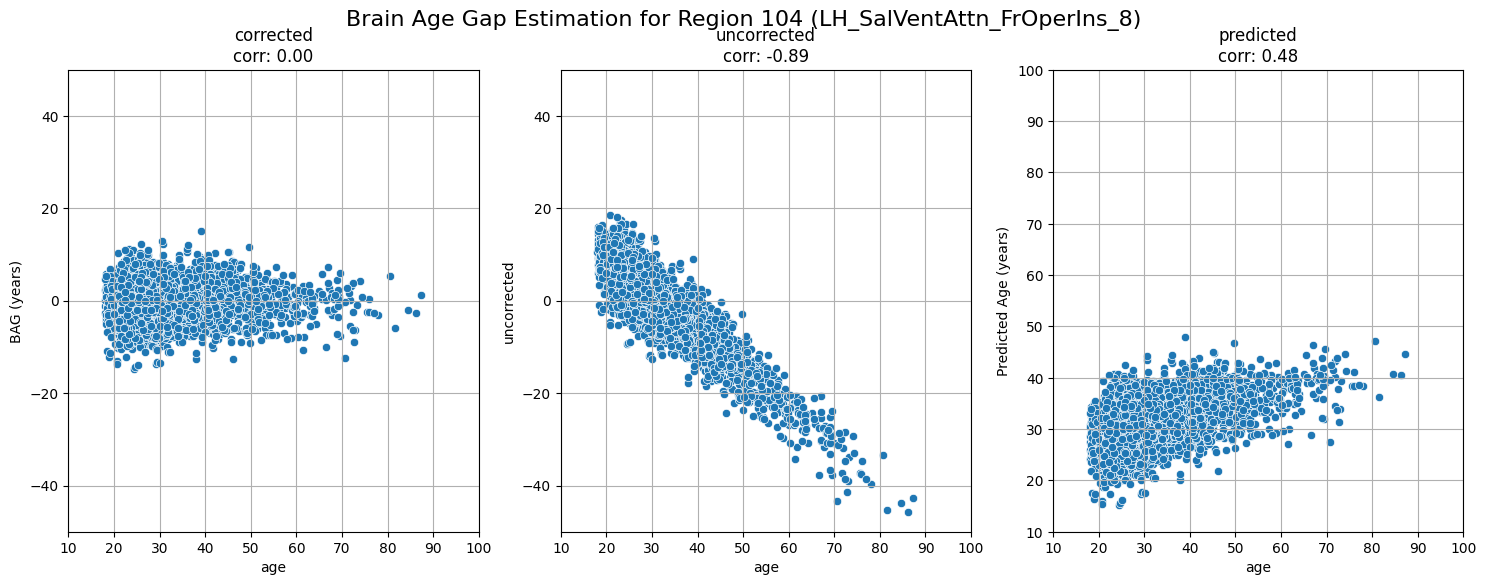

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# randomly pick a region of interest from the ~10 best regions
top_regions = result.region_metrics.sort_values("mae").head(10)["region"].values
roi = np.random.choice(top_regions)
print(f"Visualizing results for ROI: {roi} ({parcels.loc[parcels['index']==roi,'index'].values[0]})")

# visualize corrected and uncorrected BAGs for that ROI
vis = result.bag[["subject_code","session_id", roi]].rename(columns={roi:"corrected"})

vis["predicted"] = result.predicted_age[roi]
vis = vis.merge(meta[["session_id","age"]],on=["session_id"])
vis["uncorrected"] = vis["predicted"] - vis["age"]

fig, axes = plt.subplots(1,3, figsize=(18,6), sharex=True)
# share y for the first 2 plots
sns.scatterplot(vis, x="age", y="corrected", ax=axes[0])
axes[0].set_title("corrected\n" + f"corr: {np.corrcoef(vis['age'], vis['corrected'])[0,1]:.2f}")
axes[0].set_ylabel("BAG (years)")
axes[0].set_ylim(-50,50)
axes[0].grid(True)

sns.scatterplot(vis, x="age", y="uncorrected",ax=axes[1])
axes[1].set_title("uncorrected\n" + f"corr: {np.corrcoef(vis['age'], vis['uncorrected'])[0,1]:.2f}")
axes[1].set_ylim(-50,50)
axes[1].grid(True)
sns.scatterplot(vis, x="age", y="predicted",ax=axes[2])
axes[2].set_title("predicted\n" + f"corr: {np.corrcoef(vis['age'], vis['predicted'])[0,1]:.2f}")
axes[2].set_ylabel("Predicted Age (years)")
axes[2].grid(True)
axes[2].set_ylim(10,100)
axes[2].set_xlim(10,100)
# make axes[2] have its own y-axis
plt.suptitle(f"Brain Age Gap Estimation for Region {roi} ({parcels.loc[parcels['index']==roi,'label'].values[0]})", fontsize=16)
plt.show()


In [21]:
# do mixedlm on each parcel
from statsmodels.formula.api import ols, wls, mixedlm
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor, as_completed
stats = parcels.copy()

best_r2 = 0.0

def fit_parcel_model(parcel_id: int, parcel_data: pd.DataFrame, metadata: pd.DataFrame):
    # merge Age@Scan from metadata
    parcel_data = parcel_data.merge(
        metadata[["session_id", "Age@Scan", "Gender"]], on="session_id", how="left"
    ).rename(columns={"Age@Scan": "age", "Gender": "sex"}).dropna(subset=["age", "sex", "volume_mm3", "tiv", "subject_code"])
    if parcel_data.shape[0] < 10:
        return None
    # mean center age
    parcel_data["age_c"] = parcel_data["age"] - parcel_data["age"].mean()
    # fit mixedlm
    model = mixedlm("volume_mm3 ~ age_c + I(age_c ** 2) + C(sex) + tiv", parcel_data, groups=parcel_data["subject_code"])
    result = model.fit()
    return result

# iterate over parcels, collect results
with ProcessPoolExecutor(max_workers=100) as executor:
    futures = {}
    for idx, row in tqdm(parcels.iterrows(), total=parcels.shape[0]):
        parcel_id = row["index"]
        parcel_data = metric_long[metric_long["index"] == parcel_id]
        futures[executor.submit(fit_parcel_model, parcel_id, parcel_data, metadata)] = idx

for future in as_completed(futures):
    idx = futures[future]
    row = parcels.iloc[idx]
    result = future.result()
    if result is None:
        continue
    # calculate r2 of the fixed and random effects
    fixed_effects_variance = np.var(result.fittedvalues)
    random_effects_variance = result.cov_re.iloc[0, 0]
    residual_variance = result.scale
    total_variance = fixed_effects_variance + random_effects_variance + residual_variance
    r2_fixed = fixed_effects_variance / total_variance
    r2_random = random_effects_variance / total_variance

    # do F test to see of adding age^2 improves the model
    f_test_result = result.f_test("I(age_c ** 2) = 0")

    stats.loc[idx, "r2_fixed"] = r2_fixed
    stats.loc[idx, "r2_random"] = r2_random
    for col_name, col_series in zip(
        ["coef", "p", "t"], [result.params, result.pvalues, result.tvalues], strict=True
    ):
        for var in ["age_c", "I(age_c ** 2)", "C(sex)[T.Male]", "tiv"]:
            stats.loc[idx, f"{var}_{col_name}"] = col_series.get(var, np.nan)

    # add F test results
    stats.loc[idx, "age2_fvalue"] = f_test_result.fvalue
    stats.loc[idx, "age2_pvalue"] = f_test_result.pvalue

    if r2_fixed > best_r2:
        best_r2 = r2_fixed
        print(f"New best r2_fixed: {best_r2:.4f} at parcel {parcel_id}:")
        # print region name
        region_name = row["label"]
        print(f"  Region: {region_name}")
    # break
    # parcel_id = parcels["index"].unique()[idx]
    # stats.loc[stats["index"] == parcel_id, "beta_age"] = result.params.get("age_c", np.nan)
    # stats.loc[stats["index"] == parcel_id, "p_age"] = result.pvalues.get("age_c", np.nan)
    # stats.loc[stats["index"] == parcel

100%|██████████| 450/450 [00:08<00:00, 55.51it/s] 


New best r2_fixed: 0.6422 at parcel 450:
  Region: LH_Default_PFC_3
New best r2_fixed: 0.6547 at parcel 450:
  Region: PUT-DA-rh
New best r2_fixed: 0.6590 at parcel 450:
  Region: RH_Default_PFCdPFCm_2
New best r2_fixed: 0.6976 at parcel 450:
  Region: LH_Default_PFC_4
New best r2_fixed: 0.6991 at parcel 450:
  Region: RH_Default_PFCdPFCm_1
New best r2_fixed: 0.7157 at parcel 450:
  Region: NAc-shell-rh
New best r2_fixed: 0.7227 at parcel 450:
  Region: mAMY-rh


In [22]:
# multiple comparisons correction
from statsmodels.stats.multitest import multipletests

for col in ["age_c_p", "I(age_c ** 2)_p"]:
    pvals = stats[col].values
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")
    stats[f"{col}_fdr"] = pvals_corrected

In [23]:
stats[stats["label"].str.lower().str.contains("hip-")].sort_values("r2_fixed", ascending=False)

,index,label,network_label,label_7network,index_17network,label_17network,network_label_17network,atlas_name,network_id,r2_fixed,...,C(sex)[T.Male]_p,tiv_p,age_c_t,I(age_c ** 2)_t,C(sex)[T.Male]_t,tiv_t,age2_fvalue,age2_pvalue,age_c_p_fdr,I(age_c ** 2)_p_fdr
401,402,HIP-head-l-rh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.687239,...,0.129889,0.000000e+00,-7.089445,-2.970481,1.514540,51.559621,8.823760,2.989558e-03,1.446131e-12,1.079033e-02
426,427,HIP-head-l-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.685808,...,0.013022,0.000000e+00,-6.952369,-3.667538,2.483168,50.447090,13.450834,2.478191e-04,3.830356e-12,1.343948e-03
425,426,HIP-head-m-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.669053,...,0.000052,0.000000e+00,-4.511456,-4.542766,4.044489,46.483326,20.636727,5.702135e-06,6.629953e-06,5.315818e-05
400,401,HIP-head-m-rh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.653230,...,0.092185,0.000000e+00,-3.810972,-4.768794,1.683984,45.346954,22.741399,1.913809e-06,1.409269e-04,2.194719e-05
402,403,HIP-body-rh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.641461,...,0.979055,0.000000e+00,-3.926515,-7.484106,-0.026253,42.639878,56.011844,8.665229e-14,8.814414e-05,6.483218e-12
427,428,HIP-body-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.630012,...,0.075766,0.000000e+00,-3.556861,-7.248773,-1.775797,40.887738,52.544717,4.950314e-13,3.803846e-04,3.154220e-11
403,404,HIP-tail-rh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.557374,...,0.057770,1.616504e-125,-7.446144,-1.501858,1.897438,23.830416,2.255577,1.332062e-01,1.049726e-13,2.240800e-01
428,429,HIP-tail-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.556613,...,0.452231,2.956096e-119,-4.063574,-5.036332,0.751700,23.218577,25.364644,4.937117e-07,4.965098e-05,6.888430e-06


In [24]:
from sklearn.neighbors import KernelDensity


def calculate_age_weights(df):
    # 1. Estimate the density of Age in your sample
    # Bandwidth controls how "smooth" the density estimate is
    kde = KernelDensity(bandwidth=2.0).fit(df[["age"]])
    log_dens = kde.score_samples(df[["age"]])
    dens = np.exp(log_dens)

    # 2. Calculate Inverse Probability Weights
    # We want a uniform distribution, so Weight = 1 / Density
    weights = 1.0 / dens

    # 3. Normalize weights so they average to 1 (prevents inflating sample size)
    weights = weights / np.mean(weights)

    return weights



In [25]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt


def fit_normative_model(df, n_centiles=15):
    """
    df: contains [subject_code, age, sex, tiv, volume_mm3]
    """
    formula = "volume_mm3 ~ age + np.power(age, 2) + C(sex) + tiv"
    quantiles = np.linspace(0.05, 0.95, n_centiles)

    # Prediction grid
    age_range = np.linspace(df["age"].min(), df["age"].max(), 100)
    pred_df = pd.DataFrame({"age": age_range, "sex": df["sex"].mode()[0], "tiv": df["tiv"].mean()})

    # Calculate weights to make age uniform
    weights = calculate_age_weights(df)

    for q in quantiles:
        # Pass weights to the QuantReg class initialization
        model = smf.quantreg(formula, data=df)

        # Note: Weights are passed during fit in many SM models,
        # but for QuantReg we often use the 'weights' parameter in the constructor
        # if using the functional API, or handle it via a custom objective.

        # Refined Approach: Using the weights to scale the objective function
        res = model.fit(
            q=q, weights=weights, covariance_type="cluster", cov_kwds={"groups": df["subject_code"]}
        )

        pred_df[f"q_{q:.2f}"] = res.predict(pred_df)

    return pred_df, quantiles, weights, res, model


# Usage:
# centile_lines, q_list = fit_normative_model(your_dataframe)


In [26]:
def plot_normative_glow(parcel_name, df, centile_lines, q_list):
    plt.figure(figsize=(10, 6), facecolor="white")

    # 1. Plot the "Glow" (The centiles)
    for q in q_list:
        # Distance from median (0 at median, 1 at edges)
        dist = abs(q - 0.5) / 0.9
        # INVERSION: 1 at median (dark red), 0 at edges (transparent)
        intensity = 1.0 - dist

        color = plt.cm.Reds(intensity * 0.8 + 0.1)
        alpha = intensity**2  # Fast fade-out for edges

        lw = 2.5 if np.isclose(q, 0.5, atol=0.01) else 1.0

        plt.plot(
            centile_lines["age"],
            centile_lines[f"q_{q:.2f}"],
            color=color,
            alpha=alpha,
            linewidth=lw,
            zorder=3,
        )

    # 2. Plot the raw data (Subtle)
    plt.scatter(df["age"], df["volume_mm3"], alpha=0.1, color="black", s=5, zorder=1)

    # 3. Plot longitudinal connections (The 1000 participants with repeat scans)
    multi = df.groupby("subject_code").filter(lambda x: len(x) > 1)
    for _, group in multi.groupby("subject_code"):
        plt.plot(
            group["age"], group["volume_mm3"], color="blue", alpha=0.05, linewidth=0.5, zorder=2
        )

    # set ylim to +- 3 stddev of volume
    vol_mean = df["volume_mm3"].mean()
    vol_std = df["volume_mm3"].std()
    plt.ylim(vol_mean - 3 * vol_std, vol_mean + 3 * vol_std)

    plt.title(f"Normative Trend: {parcel_name}", fontsize=14)
    plt.xlabel("Age")
    plt.ylabel("Volume (mm³)")
    plt.legend(["Median (Red) -> Bounds (Faded)"], loc="upper right")
    plt.show()


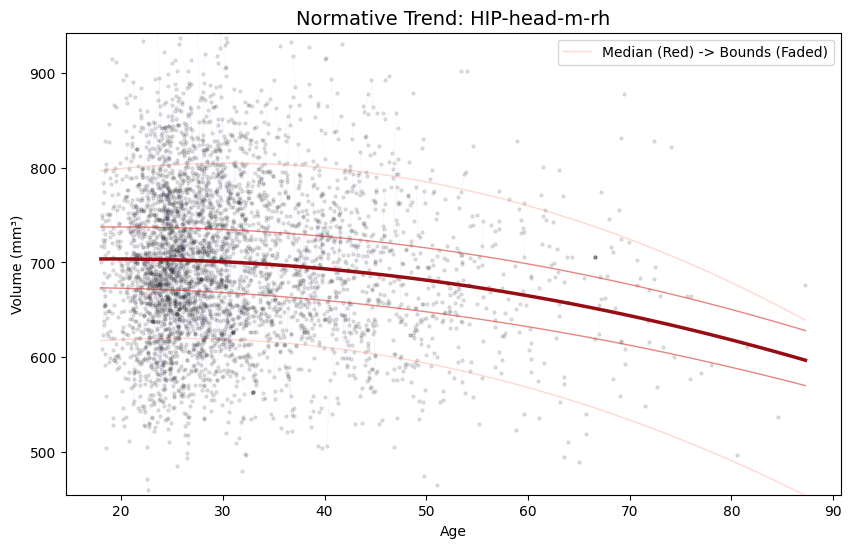

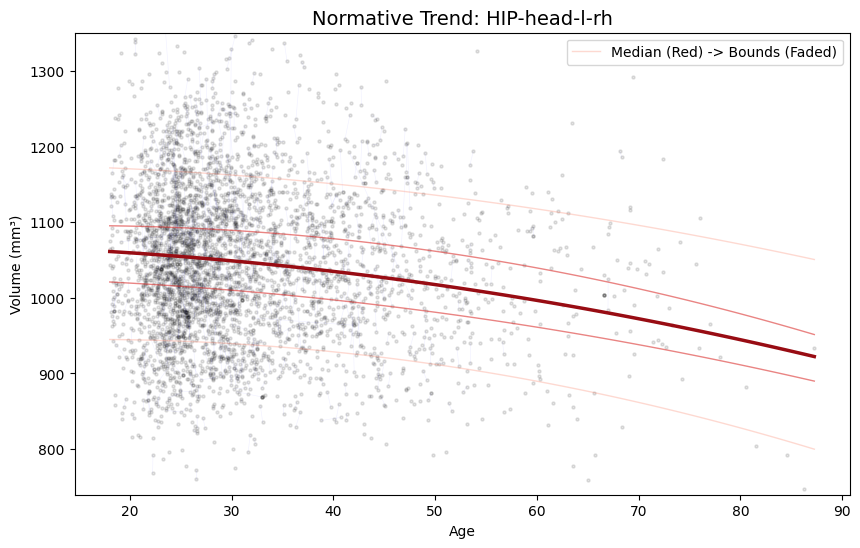

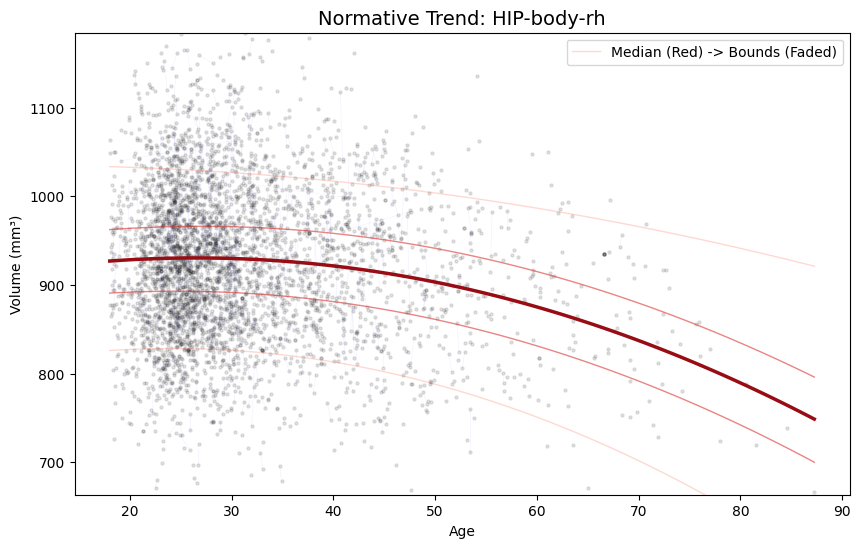

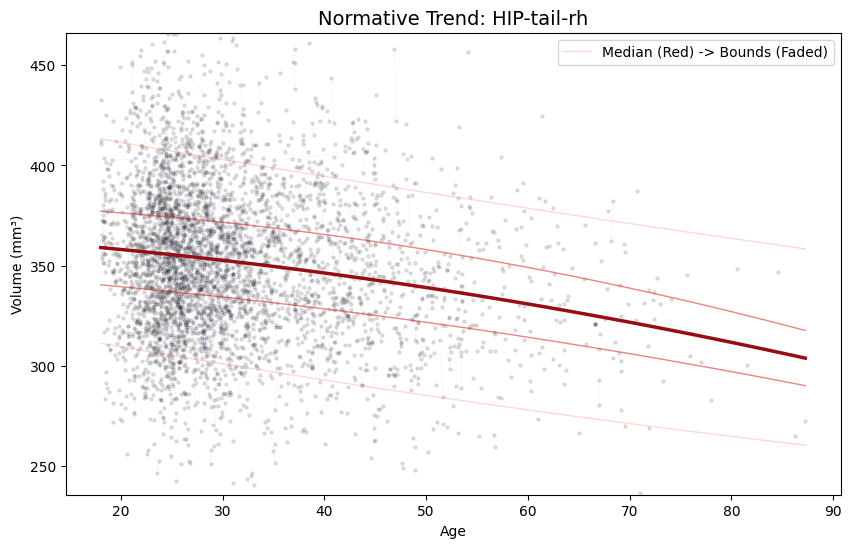

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


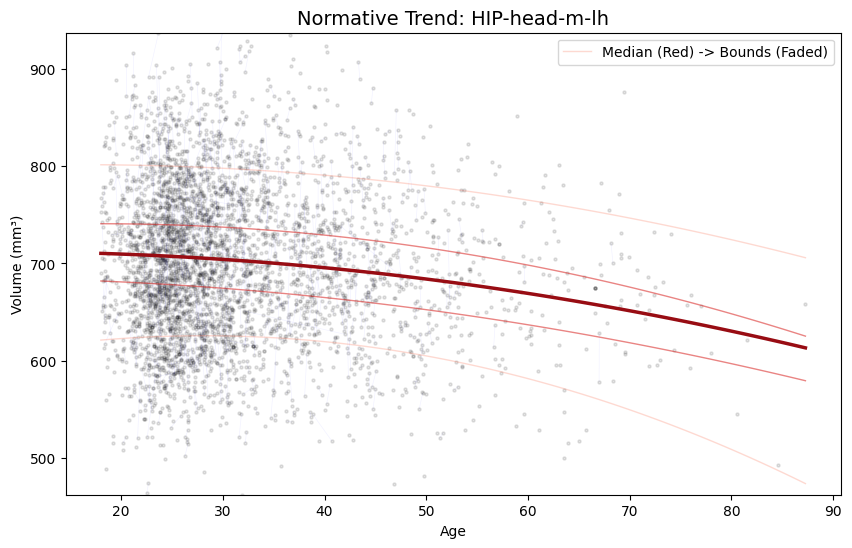

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


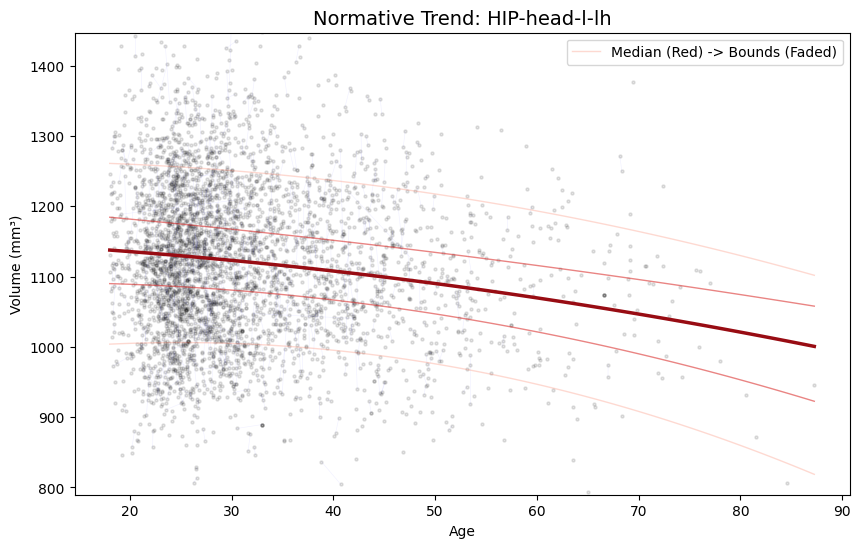

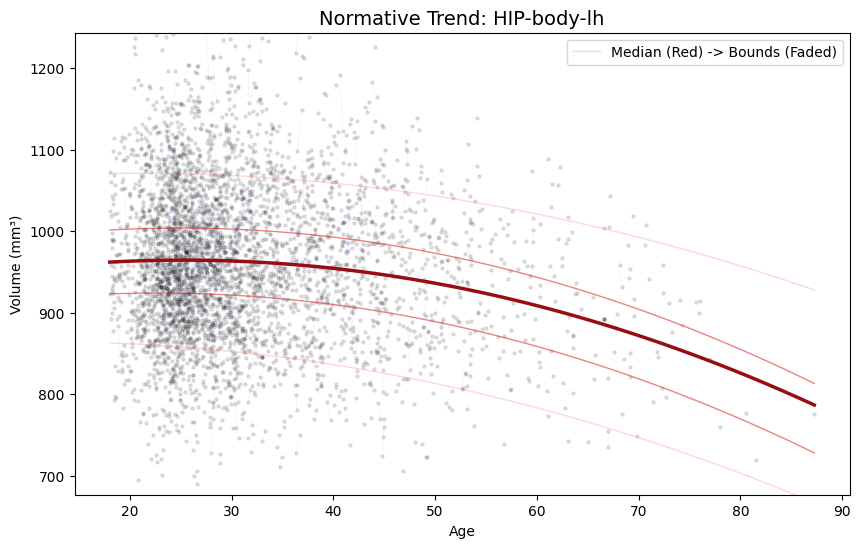

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


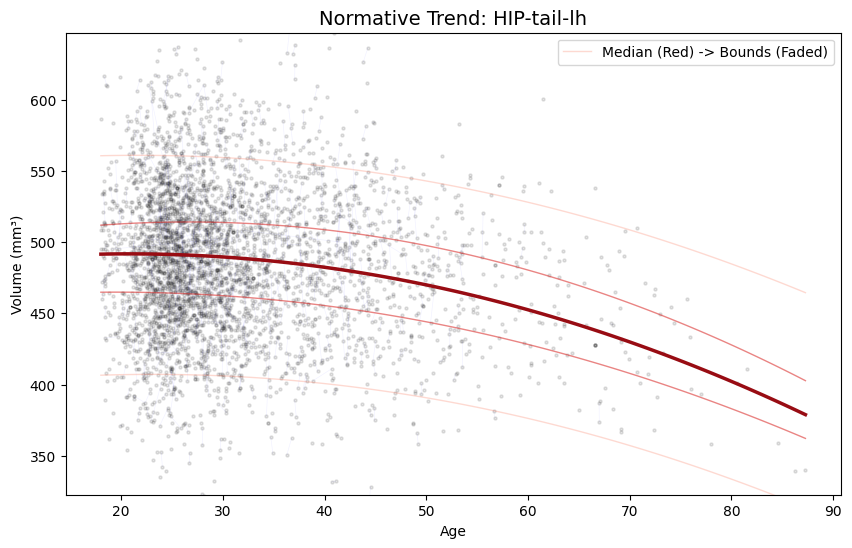

In [27]:
# for parcel_id in stats.sort_values("r2_fixed", ascending=False).head(3)["index"]:
for parcel_id in stats[stats["label"].str.lower().str.contains("hip-")]["index"]:
    parcel_data = metric_long[metric_long["index"] == parcel_id]
    df = (
        parcel_data.merge(
            metadata[["session_id", "Age@Scan", "Gender"]], on="session_id", how="left"
        )
        .rename(columns={"Age@Scan": "age", "Gender": "sex"})
        .dropna(subset=["age", "sex", "volume_mm3", "tiv", "subject_code"])
    )
    df = df[df["age"] >= 18]
    res_df, quantiles, weights, res, model = fit_normative_model(df, n_centiles=5)
    region_name = parcels[parcels["index"] == parcel_id]["label"].values[0]
    plot_normative_glow(region_name, df, res_df, quantiles)
    # break
    

In [ ]:
# stats[stats["label"].str.lower().str.contains("hipp")]
stats


,index,label,network_label,label_7network,index_17network,label_17network,network_label_17network,atlas_name,network_id,r2_fixed,...,C(sex)[T.Male]_p,tiv_p,age_c_t,I(age_c ** 2)_t,C(sex)[T.Male]_t,tiv_t,age2_fvalue,age2_pvalue,age_c_p_fdr,I(age_c ** 2)_p_fdr
0,1,LH_Vis_1,Vis,7Networks_LH_Vis_1,61.0,17Networks_LH_DorsAttnA_TempOcc_2,DorsAttnA,Schaefer2018N400n7,NaN,0.592285,...,8.570350e-02,0.000000e+00,-15.572681,0.917252,-1.718511,39.276885,0.841350,3.590616e-01,2.283298e-54,4.808181e-01
1,2,LH_Vis_2,Vis,7Networks_LH_Vis_2,193.0,17Networks_LH_DefaultC_PHC_2,DefaultC,Schaefer2018N400n7,NaN,0.568754,...,9.411029e-03,1.833653e-207,-10.069196,-0.620655,-2.596750,30.736834,0.385213,5.348590e-01,9.023068e-24,6.493881e-01
2,3,LH_Vis_3,Vis,7Networks_LH_Vis_3,1.0,17Networks_LH_VisCent_ExStr_1,VisCent,Schaefer2018N400n7,NaN,0.542718,...,2.161686e-01,1.479720e-225,-11.667057,-0.518509,-1.236780,32.062294,0.268852,6.041294e-01,2.485696e-31,7.060945e-01
3,4,LH_Vis_4,Vis,7Networks_LH_Vis_4,13.0,17Networks_LH_VisPeri_ExStrInf_1,VisPeri,Schaefer2018N400n7,NaN,0.578759,...,2.720759e-01,5.682795e-257,-14.166232,-0.202358,-1.098294,34.242279,0.040949,8.396462e-01,2.498510e-45,8.825215e-01
4,5,LH_Vis_5,Vis,7Networks_LH_Vis_5,2.0,17Networks_LH_VisCent_ExStr_2,VisCent,Schaefer2018N400n7,NaN,0.556070,...,1.112219e-03,1.099824e-231,-13.121149,-0.842188,-3.260485,32.499048,0.709281,3.997290e-01,3.639858e-39,5.181679e-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,446,THA-DP-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.510852,...,1.654787e-02,1.697747e-79,-17.015197,-0.049094,2.396602,18.878999,0.002410,9.608469e-01,1.648073e-64,9.694621e-01
446,447,NAc-shell-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.709564,...,1.603029e-04,0.000000e+00,-18.026261,-0.145083,3.774540,50.431463,0.021049,8.846522e-01,4.070708e-72,9.215057e-01
447,448,NAc-core-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.649477,...,7.766406e-02,0.000000e+00,-17.204593,0.787408,1.764404,38.966067,0.620012,4.310857e-01,6.570385e-66,5.479359e-01
448,449,pGP-lh,Subcortex,NaN,NaN,NaN,NaN,Tian2020S3,NaN,0.319060,...,6.940271e-03,1.091513e-21,-6.144793,2.965590,2.699697,9.567851,8.794723,3.037417e-03,8.438044e-10,1.087571e-02


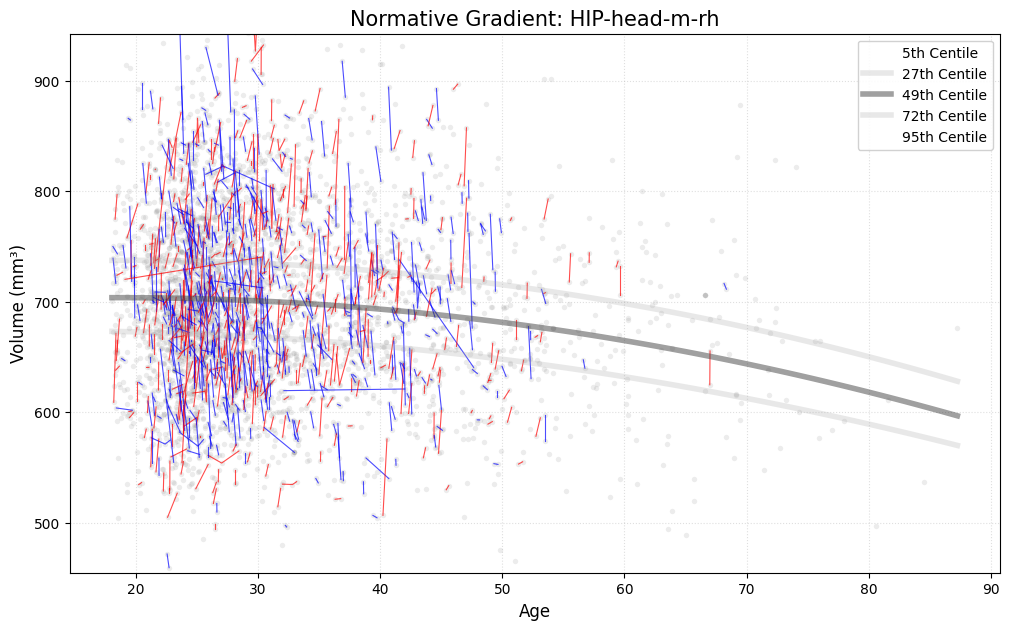

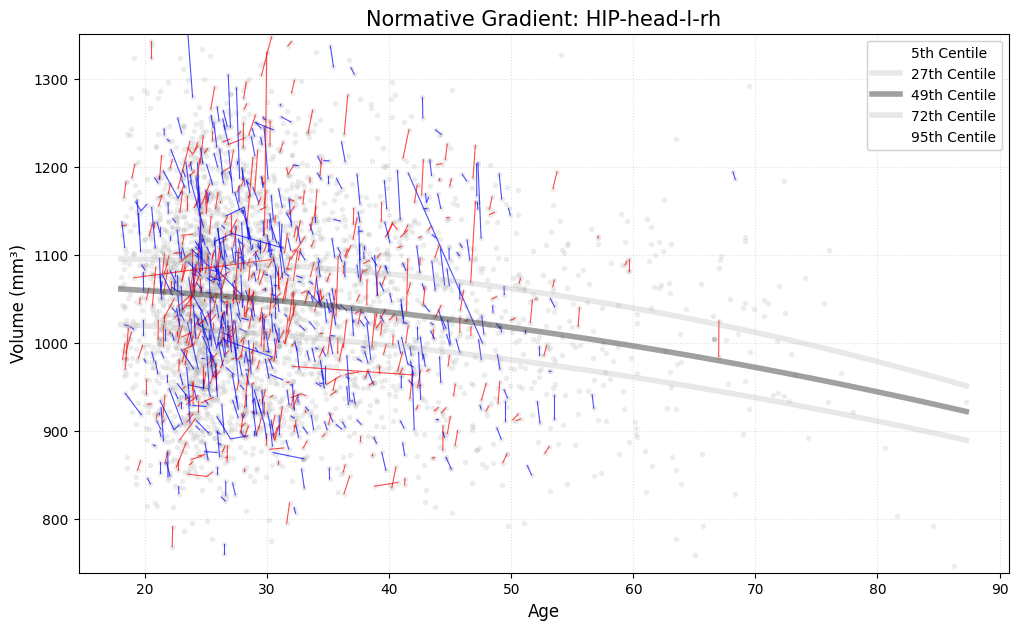

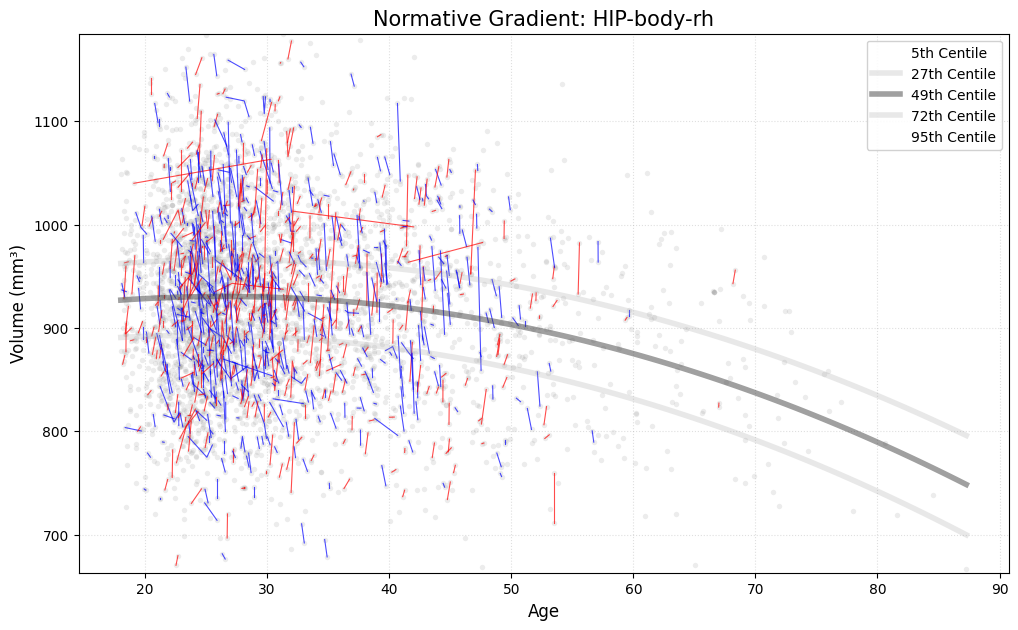

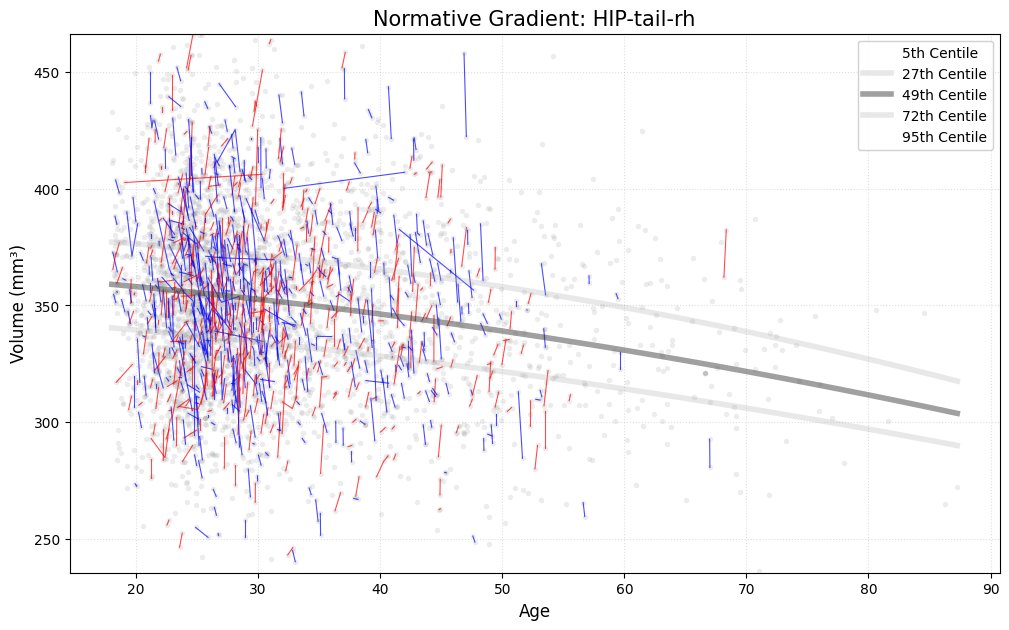

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


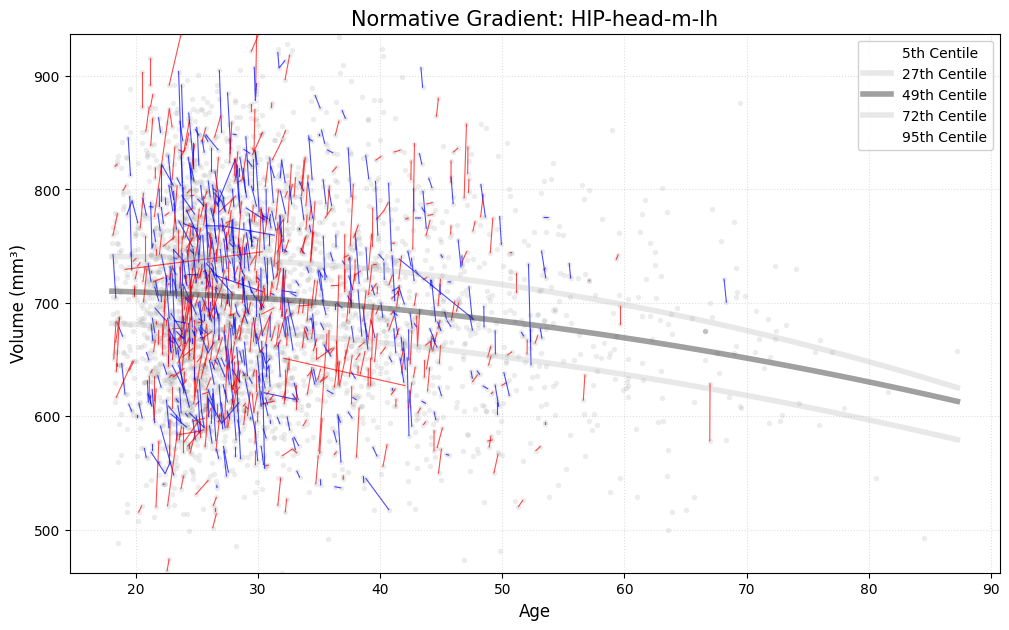

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


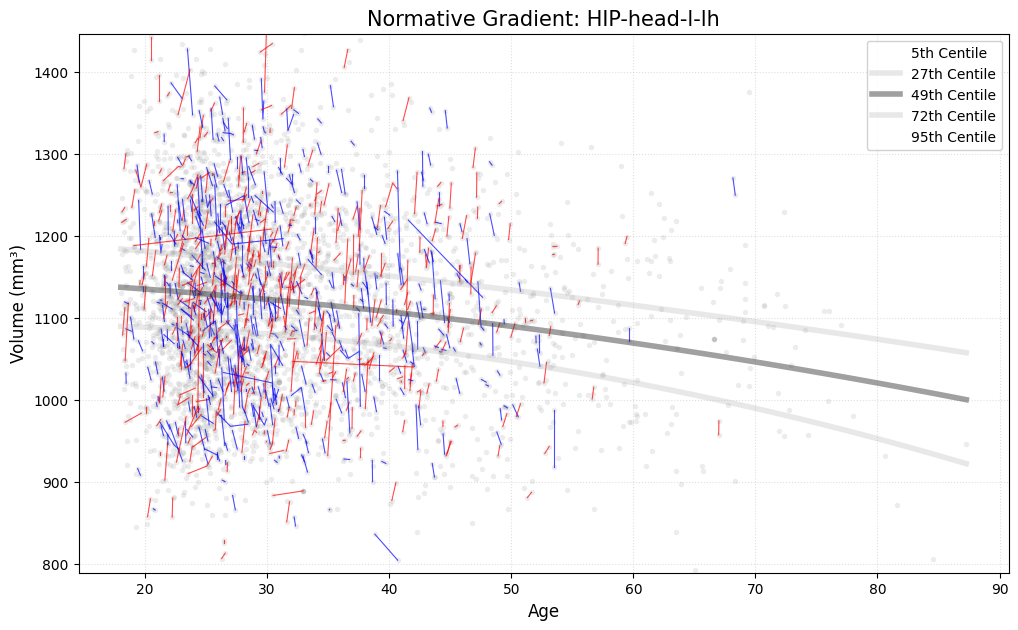

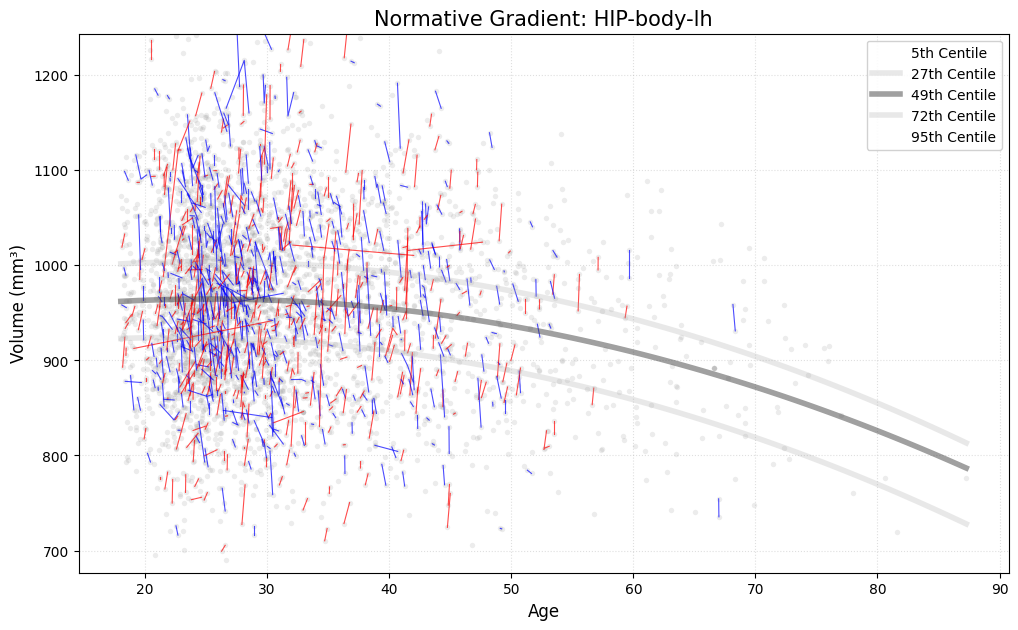

/home/galkepler/Projects/neuroalign/.venv/lib/python3.11/site-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


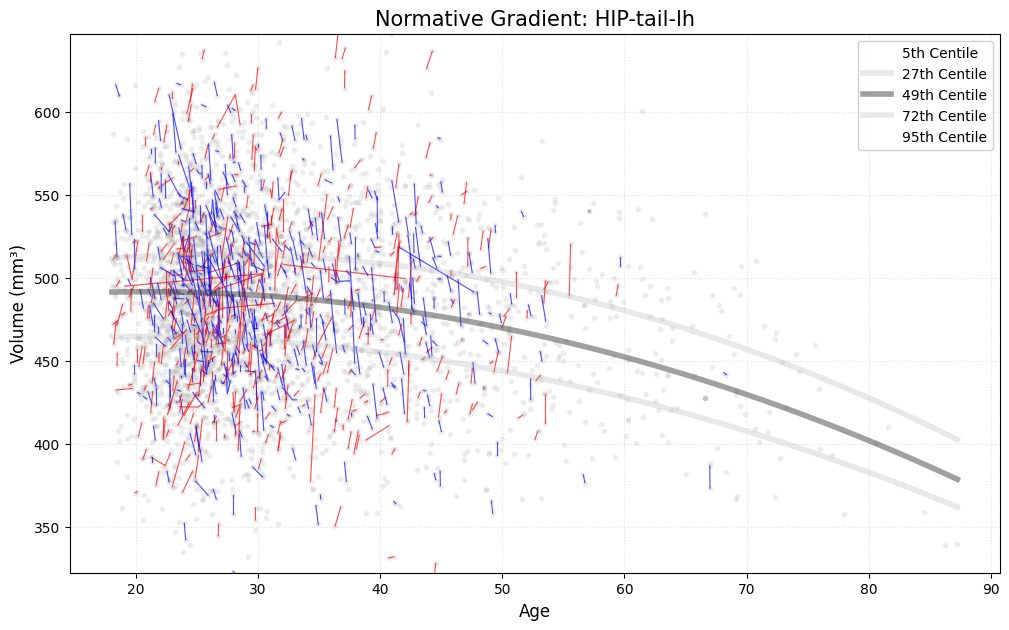

In [ ]:
# visualize normative models for age_c for a few parcels
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
from pygam import ExpectileGAM, s, f
from statsmodels.gam.api import GLMGam, BSplines
import statsmodels.formula.api as smf
import matplotlib.colors as mcolors

def fit_fast_normative_model(parcel_data: pd.DataFrame, metadata: pd.DataFrame):
    # Standard Merge
    df = (
        parcel_data.merge(
            metadata[["session_id", "Age@Scan", "Gender"]], on="session_id", how="left"
        )
        .rename(columns={"Age@Scan": "age", "Gender": "sex"})
        .dropna(subset=["age", "sex", "volume_mm3", "tiv", "subject_code"])
    )
    df = df[df["age"] >= 18]
    if df.shape[0] < 10:
        return None
    # mean center age
    df["age_c"] = df["age"] - df["age"].mean()
    # fit mixedlm
    resid_model = smf.mixedlm(
        "volume_mm3 ~ age_c + I(age_c ** 2) + C(sex) + tiv",
        df,
        groups=df["subject_code"],
    )
    resid_results = resid_model.fit()

    # We want the residuals + the intercept (the volume cleared of TIV/Sex effects)
    # This keeps the 'Age' effect in the data for the next step
    df["adj_volume"] = (
        df["volume_mm3"] - resid_results.predict(df) + resid_results.params["Intercept"]
    )

    # --- STAGE 2: Quantile Regression on adjusted volume ---
    # This is MUCH faster because we've removed the high-cardinality groups
    # We use a simple Quantile Regression with a B-Spline for Age

    # Create splines for age (3-5 knots is usually enough for brain age)
    x_spline = df[["age"]]
    bs = BSplines(x_spline, df=[5], degree=[3])

    # Fit the 50th percentile (Median)
    # Using GLMGam allows for smooth non-linear age effects
    gam_model = GLMGam.from_formula("adj_volume ~ 1", data=df, smoother=bs)
    res = gam_model.fit()

    # For true normative centiles (e.g., 5th and 95th),
    # use statsmodels.quantreg on the splines:
    # (This takes seconds, not minutes)

    return res, df



def plot_normative_parcel(parcel_name, df, n_centiles=9):
    """
    df: DataFrame with columns ['age', 'volume_mm3', 'subject_code', 'tiv', 'sex']
    """

    """
    Plots a normative model with a gradient of centiles.
    n_centiles: Number of quantile bands to plot (best if odd).
    """
    plt.figure(figsize=(12, 7))

    # 1. Setup Quantiles
    quantiles = np.linspace(0.05, 0.95, n_centiles)

    # 2. Prediction Grid
    age_grid = np.linspace(df["age"].min(), df["age"].max(), 100)
    plot_df = pd.DataFrame({"age": age_grid, "tiv": df["tiv"].mean(), "sex": df["sex"].mode()[0]})

    model_formula = "volume_mm3 ~ age + np.power(age, 2) + tiv + C(sex)"

    # 3. Loop through quantiles
    for q in quantiles:
        # Calculate color:
        # Closer to 0.5 = Light Gray/White
        # Closer to 0 or 1 = Deep Red
        dist_inv = 1.0 - (abs(q - 0.5) / 0.45)

        # We blend from a light gray (median) to a dark red (extremes)
        color = plt.cm.Grays(dist_inv * 0.7 + 0.1)

        line_alpha = dist_inv/2  # Squaring makes the fade-out smoother
        # Fit model
        res = smf.quantreg(model_formula, df).fit(
            q=q, covariance_type="cluster", cov_kwds={"groups": df["subject_code"]}
        )
        y_pred = res.predict(plot_df)
        plt.plot(
            age_grid,
            y_pred,
            color=color,
            linewidth=4,
            alpha=line_alpha,
            zorder=3,
            label=f"{int(q * 100)}th Centile",
        )

    # 4. Background Data
    sns.scatterplot(data=df, x="age", y="volume_mm3", alpha=0.15, color="gray", s=15, zorder=1)

    # Longitudinal lines
    multi_session = df.sort_values(["subject_code","session_id"]).groupby("subject_code").filter(lambda x: len(x) > 1)
    for _, group in multi_session.groupby("subject_code"):
        
        # if positive change, color in red, else blue
        color = "red" if group["volume_mm3"].iloc[-1] > group["volume_mm3"].iloc[0] else "blue"
        plt.plot(
            group["age"], group["volume_mm3"], color=color, alpha=0.7, linewidth=0.8, zorder=2
        )

    plt.title(f"Normative Gradient: {parcel_name}", fontsize=15)
    plt.xlabel("Age", fontsize=12)
    plt.ylabel("Volume (mm³)", fontsize=12)
    mean_vol = df["volume_mm3"].mean()
    std_vol = df["volume_mm3"].std()
    plt.ylim(mean_vol - 3 * std_vol, mean_vol + 3 * std_vol)
    # Place legend outside or in a clear spot
    plt.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9)
    plt.grid(True, linestyle=":", alpha=0.4)
    plt.show()

# for parcel_id in stats.sort_values("r2_fixed", ascending=False).head(3)["index"]:
for parcel_id in stats[stats["label"].str.lower().str.contains("hip-")]["index"]:
    parcel_data = metric_long[metric_long["index"] == parcel_id]
    result, df = fit_fast_normative_model(parcel_data, metadata)
    region_name = parcels[parcels["index"] == parcel_id]["label"].values[0]
    plot_normative_parcel(region_name, df, n_centiles=5)

    # 1. Define the model
    # s(0) is a spline for Age
    # f(1) is a factor term for Subject ID (random effect proxy)
    # gam = ExpectileGAM(s(0) + f(1), expectile=0.5).fit(X, y)
    # break

